In [23]:
import os

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
os.makedirs('figures', exist_ok=True)
sns.set_theme(style="darkgrid")

In [ ]:
def df_argmin(df,column_name): 
    """
    Takes the rows with smallest values of *column_name* for each p and repeat,
    i.e. can be used to take argmin by test or validation risk
    """
    out = pd.DataFrame(columns=df.columns)
    k = 0
    for p in df["p"].unique():
        for repeat in df[df["p"]==p]["repeat"].unique():
            df_tmp = df[(df["p"]==p)&(df["repeat"]==repeat)] 
            ind = df_tmp[column_name].argmin()
            out.loc[k] = df_tmp.iloc[ind] 
            k+=1
    return out

In [ ]:
df = pd.DataFrame(pd.read_pickle('logs/mnist_exp.pkl'))

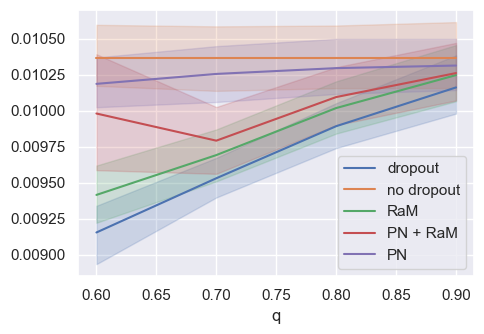

In [29]:
fig, ax = plt.subplots(figsize=(5.,3.5))
sns.lineplot(df_argmin(df,"Test risk dropout"),y="Test risk dropout",x="q",label="dropout")
sns.lineplot(df_argmin(df,"Test risk zero"),y="Test risk zero",x="q",label="no dropout")
sns.lineplot(df_argmin(df,"Test risk row"),y="Test risk row",x="q",label="RaM")
sns.lineplot(df_argmin(df,"Test risk for-back"),y="Test risk row",x="q",label="PN + RaM")
sns.lineplot(df_argmin(df,"Test risk forward"),y="Test risk forward",x="q",label="PN")
plt.ylabel("")
fig.tight_layout()
fig.savefig("figures/fig_best_test_risk.pdf")

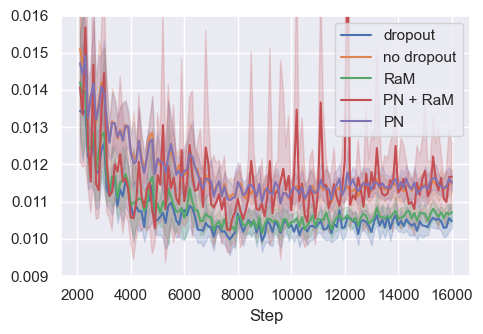

In [31]:
fig, ax = plt.subplots(figsize=(5.,3.5))
df_plot = df[(df["p"]==0.4)&(df["fraction_steps"]>0.05)&(df["fraction_steps"]<=0.4)]
sns.lineplot(df_plot,y="Test risk dropout",x="Step",label="dropout", ax=ax)
sns.lineplot(df_plot,y="Test risk zero",x="Step",label="no dropout", ax=ax)
sns.lineplot(df_plot,y="Test risk row",x="Step",label="RaM", ax=ax)
sns.lineplot(df_plot,y="Test risk for-back",x="Step",label="PN + RaM", ax=ax)
sns.lineplot(df_plot,y="Test risk forward",x="Step",label="PN", ax=ax)
ax.set_ylabel("")
plt.ylim([0.009, 0.016])
fig.tight_layout()
fig.savefig("figures/fig_test_risk_history.pdf")
